# CRM Sales Analysis

## 1. Import Data & Functions

In [18]:
import os

os.listdir()

['.ipynb_checkpoints',
 'CRM_Sales_Analysis_Python.ipynb',
 'CRM_Sales_Analysis_SQL.sql',
 'CRM_Sales_Report.ipynb',
 'Sales Dataset',
 'Untitled.ipynb']

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf

print(pd.__version__)

3.0.3


In [20]:
accounts = pd.read_csv("Sales Dataset/accounts.csv")
products = pd.read_csv("Sales Dataset/products.csv")
sales_pipeline = pd.read_csv("Sales Dataset/sales_pipeline.csv")
sales_teams = pd.read_csv("Sales Dataset/sales_teams.csv")

## 2. Dataset Overview

In [21]:
print(accounts.shape)
print(products.shape)
print(sales_pipeline.shape)
print(sales_teams.shape)

(85, 7)
(7, 3)
(8800, 8)
(35, 3)


In [22]:
accounts.info()
products.info()
sales_pipeline.info()
sales_teams.info()

<class 'pandas.DataFrame'>
RangeIndex: 85 entries, 0 to 84
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   account           85 non-null     str    
 1   sector            85 non-null     str    
 2   year_established  85 non-null     int64  
 3   revenue           85 non-null     float64
 4   employees         85 non-null     int64  
 5   office_location   85 non-null     str    
 6   subsidiary_of     15 non-null     str    
dtypes: float64(1), int64(2), str(4)
memory usage: 7.4 KB
<class 'pandas.DataFrame'>
RangeIndex: 7 entries, 0 to 6
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   product      7 non-null      str  
 1   series       7 non-null      str  
 2   sales_price  7 non-null      int64
dtypes: int64(1), str(2)
memory usage: 389.0 bytes
<class 'pandas.DataFrame'>
RangeIndex: 8800 entries, 0 to 8799
Data columns (total 8 col

In [23]:
sales_pipeline.head()

,opportunity_id,sales_agent,product,account,deal_stage,engage_date,close_date,close_value
0,1C1I7A6R,Moses Frase,GTX Plus Basic,Cancity,Won,2016-10-20,2017-03-01,1054.0
1,Z063OYW0,Darcel Schlecht,GTXPro,Isdom,Won,2016-10-25,2017-03-11,4514.0
2,EC4QE1BX,Darcel Schlecht,MG Special,Cancity,Won,2016-10-25,2017-03-07,50.0
3,MV1LWRNH,Moses Frase,GTX Basic,Codehow,Won,2016-10-25,2017-03-09,588.0
4,PE84CX4O,Zane Levy,GTX Basic,Hatfan,Won,2016-10-25,2017-03-02,517.0


## 3. Sales Cycle vs Win Rate

In [24]:
sales_pipeline[["engage_date", "close_date"]].dtypes

engage_date    str
close_date     str
dtype: object

In [25]:
sales_pipeline["engage_date"] = pd.to_datetime(sales_pipeline["engage_date"])
sales_pipeline["close_date"] = pd.to_datetime(sales_pipeline["close_date"])

In [26]:
sales_pipeline["cycle_length"] = (sales_pipeline["close_date"] - sales_pipeline["engage_date"]).dt.days

In [27]:
conditions = [sales_pipeline["cycle_length"].between(0,30), 
              sales_pipeline["cycle_length"].between(31,60), 
              sales_pipeline["cycle_length"].between(61,90), 
              sales_pipeline["cycle_length"].between(91,180), 
              sales_pipeline["cycle_length"] > 180]
choices = ["very short", "short", "medium", "long", "very long"]
sales_pipeline["sales_cycle"] = np.select(conditions, choices, default=None)
sales_pipeline["quarter"] = sales_pipeline["close_date"].dt.quarter
sales_pipeline[["engage_date", "close_date", "cycle_length", "sales_cycle", "quarter"]].head()

,engage_date,close_date,cycle_length,sales_cycle,quarter
0,2016-10-20,2017-03-01,132.0,long,1.0
1,2016-10-25,2017-03-11,137.0,long,1.0
2,2016-10-25,2017-03-07,133.0,long,1.0
3,2016-10-25,2017-03-09,135.0,long,1.0
4,2016-10-25,2017-03-02,128.0,long,1.0


In [28]:
stages = ["Won", "Lost"]
cycle_rate = (sales_pipeline
    .query("deal_stage.isin(@stages)")
    .assign(win_nb = lambda x: (x["deal_stage"] == "Won").astype(int))
    .groupby("sales_cycle", as_index = False)
    .agg(win_rate = ("win_nb", "mean"))
    .assign(win_rate = lambda x: x["win_rate"].mul(100).round(2))
    .copy())
cycle_rate

,sales_cycle,win_rate
0,long,71.13
1,medium,66.50
2,short,66.26
3,very short,57.45


<function matplotlib.pyplot.show(close=None, block=None)>

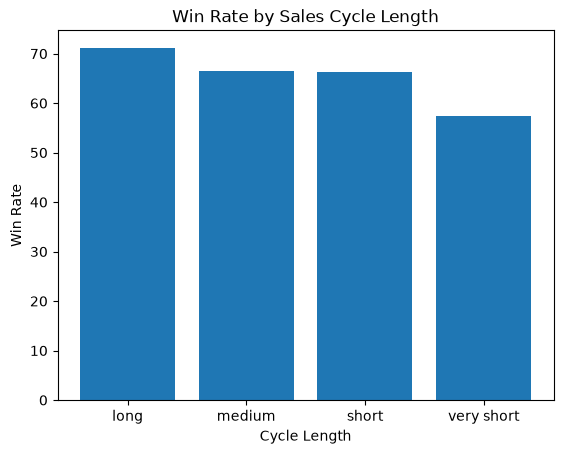

In [29]:
plt.bar(cycle_rate["sales_cycle"], cycle_rate["win_rate"])
plt.xlabel("Cycle Length")
plt.ylabel("Win Rate")
plt.title("Win Rate by Sales Cycle Length")
plt.show

Longer cycle length is associated with higher win rate.

## 4. Quarter vs Win Rate

In [30]:
Q_rate = (sales_pipeline
    .query("deal_stage.isin(@stages)")
    .assign(win_nb = lambda x: (x["deal_stage"] == "Won").astype(int))
    .groupby("quarter", as_index = False)
    .agg(win_rate = ("win_nb", "mean"))
    .assign(win_rate = lambda x: x["win_rate"].mul(100).round(2))
    .copy())
Q_rate

,quarter,win_rate
0,1.0,82.07
1,2.0,61.71
2,3.0,61.41
3,4.0,60.25


<function matplotlib.pyplot.show(close=None, block=None)>

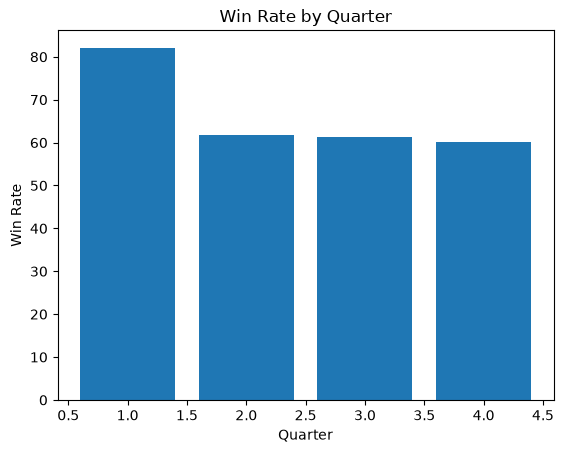

In [31]:
plt.bar(Q_rate["quarter"], Q_rate["win_rate"])
plt.xlabel("Quarter")
plt.ylabel("Win Rate")
plt.title("Win Rate by Quarter")
plt.show

Q1 has the highest win rate and it gradually goes down since Q2.

## 5. Win Rate by Sales Cycle & Quarter

In [32]:
cycle_Q = sales_pipeline[sales_pipeline["deal_stage"].isin(["Won", "Lost"])].copy()
cycle_Q["win_rate"] = (cycle_Q["deal_stage"] == "Won").astype(int)
win_rate_matrix = cycle_Q.pivot_table(index = "quarter", columns = "sales_cycle", values = "win_rate", aggfunc = "mean").mul(100).round(2)
win_rate_matrix

sales_cycle,long,medium,short,very short
quarter,,,,
1.0,82.04,78.92,80.30,86.55
2.0,69.69,67.27,63.79,55.56
3.0,70.37,64.08,67.28,55.97
4.0,67.32,63.07,62.28,55.82


<function matplotlib.pyplot.show(close=None, block=None)>

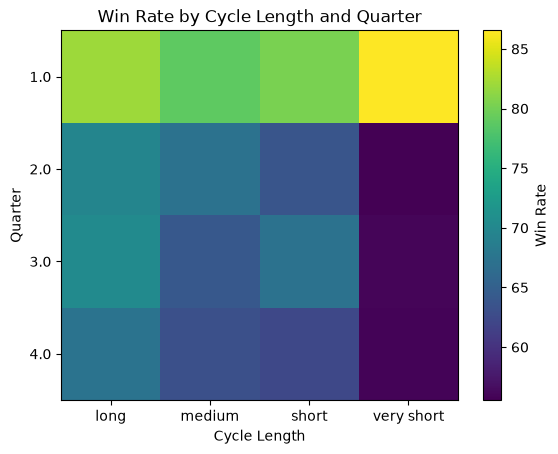

In [33]:
plt.imshow(win_rate_matrix, aspect = "auto")
plt.colorbar(label = "Win Rate")
plt.xlabel("Cycle Length")
plt.ylabel("Quarter")
plt.title("Win Rate by Cycle Length and Quarter")
plt.xticks(range(len(win_rate_matrix.columns)), win_rate_matrix.columns)
plt.yticks(range(len(win_rate_matrix.index)), win_rate_matrix.index)
plt.show

For each quarter, the longest cycle tends to have the highest win rate while the shortest the lowest, with Q1 as an exception.

## 6. Office Location vs Win Rate

In [34]:
accounts.head()

,account,sector,year_established,revenue,employees,office_location,subsidiary_of
0,Acme Corporation,technolgy,1996,1100.04,2822,United States,NaN
1,Betasoloin,medical,1999,251.41,495,United States,NaN
2,Betatech,medical,1986,647.18,1185,Kenya,NaN
3,Bioholding,medical,2012,587.34,1356,Philipines,NaN
4,Bioplex,medical,1991,326.82,1016,United States,NaN


In [35]:
l_rate = (sales_pipeline
    .query("deal_stage.isin(@stages)")
    .assign(win_nb = lambda x: (x["deal_stage"] == "Won").astype(int))
    .merge(accounts, on = "account")
    .groupby("office_location", as_index = False)
    .agg(win_rate = ("win_nb", "mean"))
    .assign(win_rate = lambda x: x["win_rate"].mul(100).round(2))
    .sort_values("win_rate", ascending = False)
    .copy())
l_rate

,office_location,win_rate
10,Panama,75.00
3,Germany,72.55
2,China,68.75
12,Poland,66.18
6,Jordan,64.20
14,United States,63.26
4,Italy,62.07
7,Kenya,61.63
1,Brazil,61.54
5,Japan,61.33


<function matplotlib.pyplot.show(close=None, block=None)>

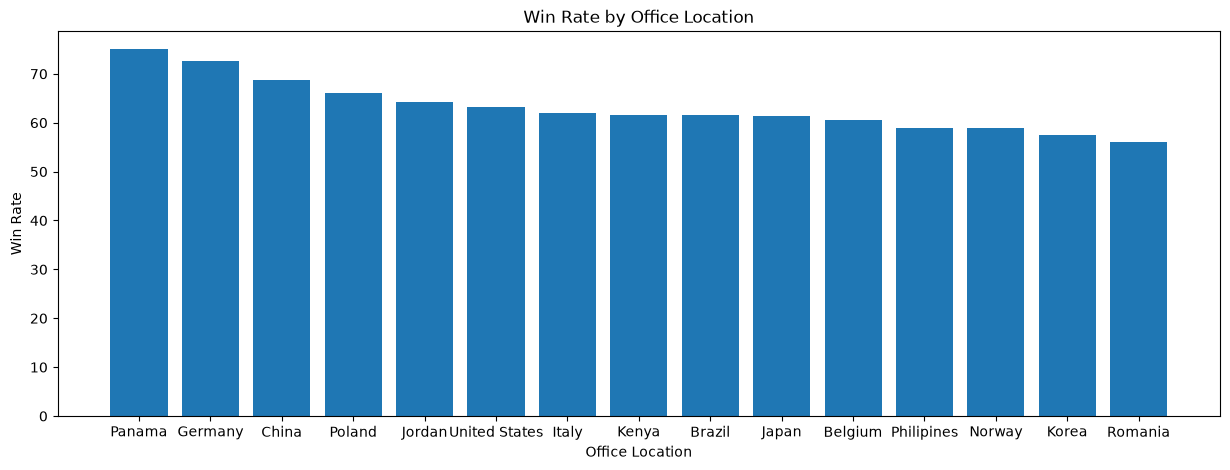

In [36]:
plt.figure(figsize = (15,5))
plt.bar(l_rate["office_location"], l_rate["win_rate"])
plt.xlabel("Office Location")
plt.ylabel("Win Rate")
plt.title("Win Rate by Office Location")
plt.show

Panama has the highest win rate, followed by Germany and China. 

## 7. Customer Revenue Distribution 

<function matplotlib.pyplot.show(close=None, block=None)>

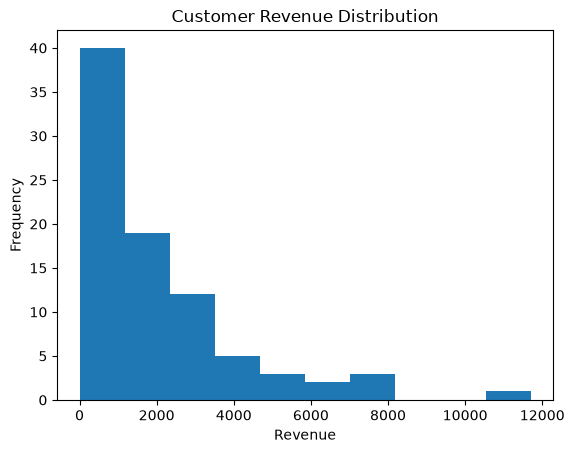

In [37]:
plt.hist(accounts["revenue"], bins = 10)
plt.xlabel("Revenue")
plt.ylabel("Frequency")
plt.title("Customer Revenue Distribution")
plt.show

The majority of the customers have revenue around or below 2000 (heavily right-skewed data)

## 8. Customer Revenue vs Win Rate

In [38]:
custom_order = ["Top Tier", "High", "Medium", "Low"]
R_rate = (sales_pipeline
    .query("deal_stage.isin(@stages)")
    .assign(win_nb = lambda x: (x["deal_stage"] == "Won").astype(int))
    .merge(accounts, on = "account")
    .copy())
R_rate["revenue_cat"] = pd.qcut(R_rate["revenue"], q=4, labels = ["Low", "Medium", "High", "Top Tier"])
R_rate["revenue_cat"] = pd.Categorical(R_rate["revenue_cat"], categories = custom_order, ordered = True)
R_rate = (R_rate    
    .groupby("revenue_cat", as_index = False)
    .agg(win_rate = ("win_nb", "mean"))
    .assign(win_rate = lambda x: x["win_rate"].mul(100).round(2)))
R_rate

,revenue_cat,win_rate
0,Top Tier,61.34
1,High,65.86
2,Medium,61.92
3,Low,63.41


<function matplotlib.pyplot.show(close=None, block=None)>

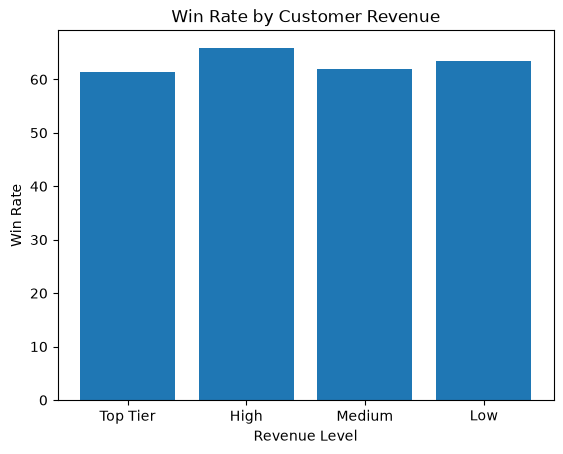

In [39]:
plt.bar(R_rate["revenue_cat"], R_rate["win_rate"])
plt.xlabel("Revenue Level")
plt.ylabel("Win Rate")
plt.title("Win Rate by Customer Revenue")
plt.show

The relationship between customer revenue level and win rate does not show a consistent pattern. 

## Regression Analysis

### Which examined factors are associated with winning after accounting for the other factors?

In [40]:
finalized = (sales_pipeline
    .merge(accounts, on = "account")
    .query("deal_stage.isin(@stages)")
    .assign(won = lambda x: (x["deal_stage"] == "Won").astype(int)))

For sales cycle, long cycle is assumed as the reference category.

For quarter, Q1 is assumed as the reference category.

Considering office location, set the value with the largest deal volumn (deal_stage = won or lost) as the reference category for more stable comparison.

United States is thus the reference category.

In [41]:
finalized["office_location"].value_counts()

office_location
United States    5555
Korea             193
Belgium           104
Panama            100
Italy              87
Kenya              86
Philipines         85
Norway             85
Jordan             81
Japan              75
Poland             68
Brazil             52
Germany            51
China              48
Romania            41
Name: count, dtype: int64

In [42]:
model = smf.logit("won ~ C(sales_cycle, Treatment(reference = 'long')) + C(quarter, Treatment(reference = 1)) + C(office_location, Treatment(reference = 'United States')) + revenue", data = finalized).fit()
model.summary()

Optimization terminated successfully.
         Current function value: 0.642850
         Iterations 5


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    won   No. Observations:                 6711
Model:                          Logit   Df Residuals:                     6689
Method:                           MLE   Df Model:                           21
Date:                Wed, 23 Sep 2026   Pseudo R-squ.:                 0.02325
Time:                        13:10:27   Log-Likelihood:                -4314.2
converged:                       True   LL-Null:                       -4416.9
Covariance Type:            nonrobust   LLR p-value:                 3.148e-32
==========================================================================================================================================
                                                                             coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                  1.7698      0.118     15.037      0.000       1.539       2.000
C(sales_cycle, Treatment(reference='long'))[T.medium]                     -0.1944      0.081     -2.412      0.016      -0.352      -0.036
C(sales_cycle, Treatment(reference='long'))[T.short]                      -0.1975      0.108     -1.826      0.068      -0.409       0.014
C(sales_cycle, Treatment(reference='long'))[T.very short]                 -0.5258      0.071     -7.429      0.000      -0.665      -0.387
C(quarter, Treatment(reference=1))[T.2.0]                                 -0.9525      0.113     -8.412      0.000      -1.174      -0.731
C(quarter, Treatment(reference=1))[T.3.0]                                 -0.9608      0.113     -8.488      0.000      -1.183      -0.739
C(quarter, Treatment(reference=1))[T.4.0]                                 -1.0147      0.113     -8.956      0.000      -1.237      -0.793
C(office_location, Treatment(reference='United States'))[T.Belgium]       -0.0606      0.205     -0.296      0.767      -0.461       0.340
C(office_location, Treatment(reference='United States'))[T.Brazil]        -0.0879      0.292     -0.301      0.763      -0.660       0.485
C(office_location, Treatment(reference='United States'))[T.China]          0.2847      0.317      0.899      0.369      -0.336       0.906
C(office_location, Treatment(reference='United States'))[T.Germany]        0.4687      0.318      1.474      0.140      -0.155       1.092
C(office_location, Treatment(reference='United States'))[T.Italy]         -0.0612      0.227     -0.270      0.787      -0.505       0.383
C(office_location, Treatment(reference='United States'))[T.Japan]         -0.0631      0.243     -0.259      0.795      -0.540       0.414
C(office_location, Treatment(reference='United States'))[T.Jordan]         0.0356      0.237      0.150      0.881      -0.429       0.500
C(office_location, Treatment(reference='United States'))[T.Kenya]         -0.0295      0.227     -0.130      0.897      -0.475       0.416
C(office_location, Treatment(reference='United States'))[T.Korea]         -0.1848      0.162     -1.140      0.254      -0.502       0.133
C(office_location, Treatment(reference='United States'))[T.Norway]        -0.1458      0.225     -0.649      0.517      -0.587       0.295
C(office_location, Treatment(reference='United States'))[T.Panama]         0.5439      0.235      2.315      0.021       0.083       1.004
C(office_location, Treatment(reference='United States'))[T.Philipines]    -0.1889      0.226     -0.836      0.403      -0.631       0.254
C(office_location, Treatment(reference='United States'))[T.Poland]         0.1637      0.262      0.624      0.533      -0.350       0.678
C(office_location, Treatment(reference='Unit

log-odds => odds ratio

In [43]:
print(np.exp(model.params["C(sales_cycle, Treatment(reference='long'))[T.medium]"]))
print(np.exp(model.params["C(sales_cycle, Treatment(reference='long'))[T.very short]"]))
print(np.exp(model.params["C(quarter, Treatment(reference=1))[T.2.0]"]))
print(np.exp(model.params["C(quarter, Treatment(reference=1))[T.3.0]"]))
print(np.exp(model.params["C(quarter, Treatment(reference=1))[T.4.0]"]))
print(np.exp(model.params["C(office_location, Treatment(reference='United States'))[T.Panama]"]))

0.8233117040930955
0.5910719030971996
0.3857768678084558
0.3825685282538505
0.3625159476629508
1.722676167900145


### Overall Results

The model generally provides statistically significant insights into whether a deal is won or lost compared to the null model with no predictors (LLR p-value: 3.148e-32).

However, the variables examined can contribute only limitedly to the explanation of the variation in deal outcomes (Pseudo R-squ.: 0.02325).

### Sales Cycle

Long sales cycle is taken as the reference category and other variables -- quarter, office location, and revenue -- are controlled.

Medium cycle shows significantly lower with 0.82x odds of becoming a won deal.

Short cycle does not statistically demonstrate lower or different odds of winning with significance (P>|z| > 0.05, 95% confidence interval contains 0).

Very short cycle shows much lower with 0.59x odds of being a won deal with great statistical significance.

### Quarter

Q1 is taken as the reference category while other variables are controlled.
    
Q2, Q3, and Q4 have lower odds of winning with statistical significance (0.39x, 0.38x, 0.36x respectively).
    
The results correspond to the higher win rate outcome in Q1 examined earlier.

### Customer Office Location

There is no sufficient evidence to display correlation between office location and deal winning, after controlling other examined variables.

However, Panama is shown to have 1.72x odds of winning compared with United States as the reference location with statistical significance.

### Customer Revenue 

There is lack of statistical significance for an independent relationship between continuous revenue and the odds of winning.

### Is the relationship between sales cycle and win rate subject to quarter differences?

In [44]:
model1 = smf.logit("won ~ C(sales_cycle, Treatment(reference = 'long')) * C(quarter, Treatment(reference = 1)) + C(office_location) + revenue", data = finalized).fit()
model1.summary()

Optimization terminated successfully.
         Current function value: 0.641598
         Iterations 6


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    won   No. Observations:                 6711
Model:                          Logit   Df Residuals:                     6680
Method:                           MLE   Df Model:                           30
Date:                Wed, 23 Sep 2026   Pseudo R-squ.:                 0.02515
Time:                        13:10:31   Log-Likelihood:                -4305.8
converged:                       True   LL-Null:                       -4416.9
Covariance Type:            nonrobust   LLR p-value:                 3.221e-31
=======================================================================================================================================================================
                                                                                                          coef    std err          z      P>|z|      [0.025      0.975]
-----------------------------------------------------------------------------------------------------------------------------------------------------------------------
Intercept                                                                                               1.4610      0.274      5.332      0.000       0.924       1.998
C(sales_cycle, Treatment(reference='long'))[T.medium]                                                  -0.1983      0.250     -0.793      0.428      -0.688       0.292
C(sales_cycle, Treatment(reference='long'))[T.short]                                                   -0.1118      0.359     -0.311      0.756      -0.816       0.592
C(sales_cycle, Treatment(reference='long'))[T.very short]                                               0.3513      0.289      1.217      0.224      -0.214       0.917
C(quarter, Treatment(reference=1))[T.2.0]                                                              -0.6872      0.211     -3.264      0.001      -1.100      -0.274
C(quarter, Treatment(reference=1))[T.3.0]                                                              -0.6544      0.214     -3.058      0.002      -1.074      -0.235
C(quarter, Treatment(reference=1))[T.4.0]                                                              -0.7900      0.214     -3.688      0.000      -1.210      -0.370
C(office_location)[T.Brazil]                                                                           -0.0162      0.354     -0.046      0.963      -0.710       0.678
C(office_location)[T.China]                                                                             0.3534      0.375      0.943      0.346      -0.381       1.088
C(office_location)[T.Germany]                                                                           0.5429      0.377      1.442      0.149      -0.195       1.281
C(office_location)[T.Italy]                                                                            -0.0034      0.303     -0.011      0.991      -0.598       0.591
C(office_location)[T.Japan]                                                                            -0.0091      0.317     -0.029      0.977      -0.631       0.613
C(office_location)[T.Jordan]                                                                            0.1089      0.312      0.350      0.727      -0.502       0.720
C(office_location)[T.Kenya]                                                                             0.0419      0.303      0.138      0.890      -0.552       0.636
C(office_location)[T.Korea]                                                                            -0.1121      0.261     -0.429      0.668      -0.624       0.400
C(office_location)[T.Norway]                                                                           -0.0810      0.302     -0.268      0.788      -0.672       0.510
C(office_location)[T.Panama]                     

log-odds => odds ratio

In [47]:
print(np.exp(model1.params["C(quarter, Treatment(reference=1))[T.2.0]"]))
print(np.exp(model1.params["C(quarter, Treatment(reference=1))[T.3.0]"]))
print(np.exp(model1.params["C(quarter, Treatment(reference=1))[T.4.0]"]))
print(np.exp(model1.params["C(sales_cycle, Treatment(reference='long'))[T.very short]"]))
print(-0.9544 + 0.3513, np.exp(-0.9544 + 0.3513))
print(-0.9756 + 0.3513, np.exp(-0.9756 + 0.3513))
print(-0.8448 + 0.3513, np.exp(-0.8448 + 0.3513))

0.5029909357784356
0.5197784572022892
0.4538618798114547
1.4208733980918302
-0.6031 0.5471129543392157
-0.6243000000000001 0.535636242688608
-0.4935 0.6104859497675367


### Overall Results

BASELINE = C(sales_cycle)[T.long]:C(quarter)[T.1.0] = intercept = (log odds: 1.4610)

The model generally provides statistically significant insights into whether a deal is won or lost compared to the null model with no predictors (LLR p-value: 3.221e-31).

However, the variables examined show only limited improvement to the explanation of the variation in deal outcomes (Pseudo R-squ.: 0.02515).

### Sales Cycle Effect in Q1

Compared with the long cycle (reference), effect of different sales cycles on winning is not statistically significant in Q1.

### Quarter Effect for Long-cycle Deals

Compared with Q1 (reference), considering long sales cycle, Q2, Q3, and Q4 exhibit significantly around 50% lower odds of winning (0.50x, 0.52x, 0.45x respectively).

### Sales Cycle x Quarter Effect

Assuming long sales cycle, Q1 = reference:

Only the very short cycle holds statistical significance with effect depending on Q2, Q3, and Q4.

Considering very short cycle in (log-odds, odds ratio):

Q1: +0.351, 1.42x

Q2: -0.603, 0.55x 

Q3: -0.624, 0.54x

Q4: -0.494, 0.61x

Conclusion: 

Very-short deals have higher estimated odss of winning compared to long deals in Q1 but without statistical significance.

Very-short deals have lower estimated odds (around 40-50% lower odds of winning) compared to long deals across Q2-4 with statistical significance.